In [ ]:
# These are the 2 necessary imports we need. pathlib.Path is optional here but makes life easier overall working with paths
%pip install h5py
%pip install matplotlib

from pathlib import Path # this is a python standard library that always comes with an installation of python
import h5py
import matplotlib.pyplot as plt

A concept to know here is, that python dictionaries are basically like matlab structs.
In matlab structs, you can call the fields like such:
```
struct_variable.field = value
```
In python it is similar but simpler.
The quick introduction to dictionaries is important, as the h5py library,
with which you will load your mat files, behaves very similarly.

You can create a dictionary in many ways:

In [39]:
# this is the up front approach. Here you know your values and 'fields'. In python they are called keys
def my_function():
    print('hi from function')

my_dict = {
    'field1': 'value1',
    'field2': 12,
    'field3': [1, 2, 3, 4],
    'field4': {
        'subfield1': 'nested entry',
        'subfield2': [[1,2,3],[4,5,6]]
    },
    'field5': my_function
}

# you can also add an entry afterwards
my_dict['field6'] = 'i am new'


As you can see, you can fill the dictionary with basically anything.
To retrieve the values of the fields/keys, do as follows:

In [40]:
print(
    my_dict['field6']
)
my_dict['field5']() # this is a special case as we stored the function before in the field and call it now by appending the (). Mostly not useful

i am new
hi from function


In [41]:
# you find the keys of the dict as such:
dict_keys = my_dict.keys()
print(dict_keys)

dict_keys(['field1', 'field2', 'field3', 'field4', 'field5', 'field6'])


In [42]:
# you can also easily loop the dictionary
# this particular way would return the keys
for i in my_dict:
    print(i)

field1
field2
field3
field4
field5
field6


In [43]:
# here you will get all the items without the keys
for i in my_dict.values():
    print(i)

value1
12
[1, 2, 3, 4]
{'subfield1': 'nested entry', 'subfield2': [[1, 2, 3], [4, 5, 6]]}
<function my_function at 0x000002038A67A520>
i am new


In [44]:
# you can also get both
for key, item in my_dict.items():
    print(key, item)

field1 value1
field2 12
field3 [1, 2, 3, 4]
field4 {'subfield1': 'nested entry', 'subfield2': [[1, 2, 3], [4, 5, 6]]}
field5 <function my_function at 0x000002038A67A520>
field6 i am new


In [45]:
# to access the subfields, do the following:
subfield1 = my_dict['field4']['subfield1']
print(subfield1)

nested entry


Onto the h5py. This is a python wrapper for the hdf5 project which is a generalized data storage format.

['Ch1', 'Ch2', 'Ch3', 'Ch31', 'Ch32', 'Ch4', 'Ch5', 'Ch6', 'file']
these are the channel keys:
<KeysViewHDF5 ['comment', 'interval', 'length', 'offset', 'scale', 'start', 'times', 'title', 'units', 'values']>
7994627


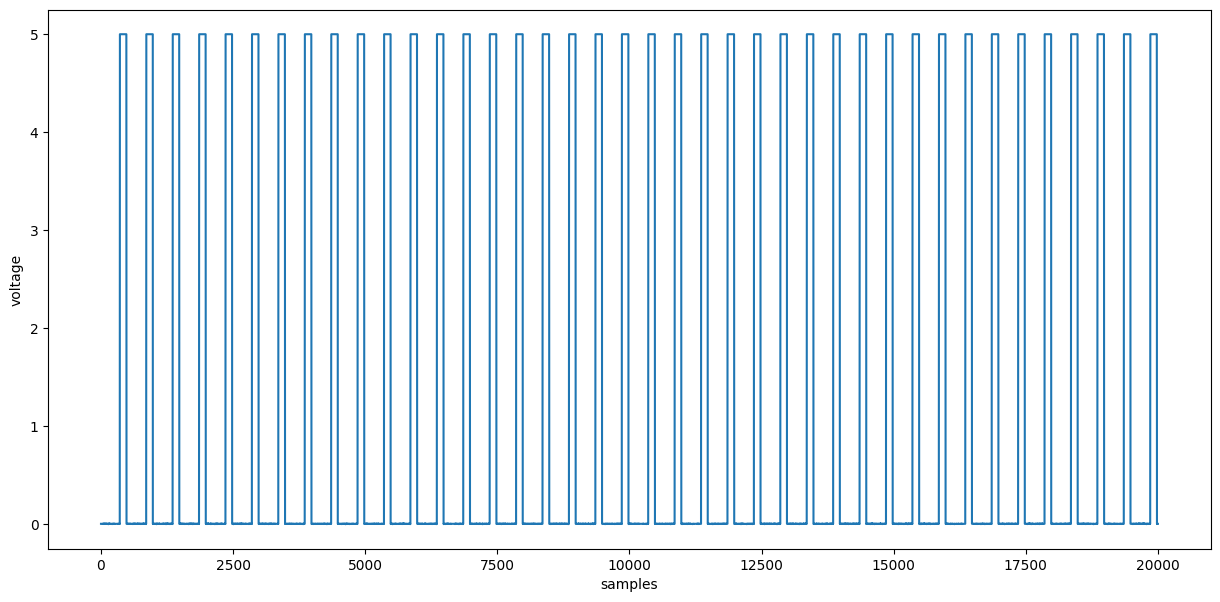

In [ ]:
path = Path(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\ADN\ADNFH5\analysis\Data5\tones-95\Data5-tones-95.mat") # the Path function helps us with escape characters of the path
file = h5py.File(path, 'r') # we want this as readonly to not mess with the file

# here we can see the dataset of the file
# here you can see the different types of channels in the file
print(list(file.keys()))

ch6 = file['Ch6']
print('these are the channel keys:')
print(ch6.keys())

#here are the values. The [0] is necessary as it stores the array inside a list and we want to get just the array
ch6_values = ch6['values'][0]
# length of the values array
print(len(ch6_values[:]))

width, height = 15, 7
plt.figure(figsize=(width, height))
plt.plot(ch6_values[200000:220000]) # Careful, Python indexing is exclusive. this will plot from the 200.000 element to the 219.999th element excluding the 220.000th element
plt.xlabel('samples')
plt.ylabel('voltage')
plt.show()


